Generate ROC AUC main figure for manuscript

In [1]:
import itertools as it
import os
import sys
from glob import glob

import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, balanced_accuracy_score, f1_score
from plotnine import *
from tqdm.notebook import tqdm_notebook

sys.path.append("/home/b.y.yang/sotiraslab/BradenADLongitudinalPrediction/code")
from project_utils import *

# Extract leave-out accuracy metrics + compute aggregated accuracy metrics

In [2]:
def get_aggregated_metrics(model_dict):

    # get aggregated out-of-sample predictions
    y_test_all, y_pred_all, y_score_all = [], [], []
    for site, d in model_dict["trained_models"].items():
        X_test = d["X_test"]
        m = d["model"].best_estimator_
        y_pred = m.predict(X_test)
        y_score = m.decision_function(X_test)
        
        y_test_all.append(d["y_test"])
        y_pred_all.append(y_pred)
        y_score_all.append(y_score)
    y_test = np.concatenate(y_test_all)
    y_pred = np.concatenate(y_pred_all)
    y_score = np.concatenate(y_score_all)

    # get confusion matrix
    conf_mat = confusion_matrix(y_true=y_test, y_pred=y_pred)
    if conf_mat.shape[0] != 2 or conf_mat.shape[1] != 2:
        TN, FN, FP, TP = np.nan, np.nan, np.nan, np.nan
    else:
        TN = conf_mat[0,0]; FN = conf_mat[1,0]; FP = conf_mat[0,1]; TP = conf_mat[1,1]
    
    # return accuracy metrics
    return {
        "roc_auc": roc_auc_score(y_test, y_score),
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "sensitivity": (TP) / (TP + FN),
        "specificity": (TN) / (TN + FP),
        "positive_predictive_value": (TP) / (TP + FP),
        "negative_predictive_value": (TN) / (TN + FN),
    }

def get_acc_list(
    wdir,
    feature_list = ["avn", "an", "vn", "av"],
    year_list = [1,2,3,4,5],
    leave_out_experiment_list = ["site", "tracer"]
):

    acc_list = []
    n = len(feature_list) * len(year_list) * len(leave_out_experiment_list)
    for f, t, group_col in tqdm_notebook(list(it.product(feature_list, year_list, leave_out_experiment_list)), desc = "extracting accuracy metrics", total = n):
        try:
            model_dict = joblib.load(os.path.join(wdir, f"{f}__svm__{t}yr__{group_col}.joblib"))
        except FileNotFoundError:
            print(f"skipping {f}__svm__{t}yr__{group_col}.joblib")
            continue

        # group-specific accuracy metrics
        for group, m in model_dict["trained_models"].items():
            for k in ["train_metrics", "test_metrics"]:
                d = m[k]
                d["features"] = f
                d["time_window"] = t
                d["leave_out_group"] = group
                d["model"] = "svm"
                d["eval_dataset"] = k
                acc_list.append(d)

        # aggregated metrics
        acc_agg = get_aggregated_metrics(model_dict)
        acc_agg["features"] = f
        acc_agg["time_window"] = t
        acc_agg["leave_out_group"] = f"aggregated_{group_col}"
        acc_agg["model"] = "svm"
        acc_agg["eval_dataset"] = "test_metrics"
        acc_list.append(acc_agg)
    
    return acc_list

def get_scores_for_delong(
    wdir,
    feature_list = ["avn", "an", "vn", "av"],
    year_list = [1,2,3,4,5],
    leave_out_experiment_list = ["site", "tracer"]
):
    y_score_df_list = []
    n = len(feature_list) * len(year_list) * len(leave_out_experiment_list)
    for f, t, group_col in tqdm_notebook(list(it.product(feature_list, year_list, leave_out_experiment_list)), desc = "computing y-score", total = n):
        try:
            model_dict = joblib.load(os.path.join(wdir, f"{f}__svm__{t}yr__{group_col}.joblib"))
        except FileNotFoundError:
            print(f"skipping {f}__svm__{t}yr__{group_col}.joblib")
            continue
    
        # group-specific accuracy metrics
        for group, d in model_dict["trained_models"].items():
    
            model = d["model"].best_estimator_
            X_test, y_test = d["X_test"], d["y_test"]
            y_score = model.decision_function(X_test)
    
            y_score_df = pd.DataFrame({
                "features": f,
                "time_window": t,
                "leave_out_group": group,
                "model": "svm",
                "y_true": y_test,
                "y_score": y_score
            })
            y_score_df_list.append(y_score_df)
    return pd.concat(y_score_df_list).reset_index()

In [ ]:
wdir = "/ceph/chpc/shared/aristeidis_sotiras_group/b.y.yang_scratch/BradenADLongitudinalPrediction/3_TrainTestModel/simplified_experiments"

acc_list_base = get_acc_list(os.path.join(wdir, "base"))
# acc_list_combat = get_acc_list(os.path.join(wdir, "combat"))
# acc_list_ensemble = get_acc_list(os.path.join(wdir, "ensemble"))

In [5]:
acc_df = pd.DataFrame(acc_list_base)
acc_df["experiment"] = "base"
# combat_df = pd.DataFrame(acc_list_combat)
# combat_df["experiment"] = "combat"

# acc_df = pd.concat([base_df, combat_df])
metrics_col = acc_df.loc[:, "roc_auc":"negative_predictive_value"].columns
id_col = acc_df.loc[:, "features":"experiment"].columns
acc_long = acc_df.melt(id_vars = id_col, value_vars = metrics_col, var_name = "metric", value_name = "value")

# acc_long.to_csv("/home/b.y.yang/sotiraslab/BradenADLongitudinalPrediction/code/3_TrainTestModel/eval/acc_metrics.csv", index = False)

### Centiloid vs. no Centiloid

In [ ]:
wdir = "/ceph/chpc/shared/aristeidis_sotiras_group/b.y.yang_scratch/BradenADLongitudinalPrediction/3_TrainTestModel/centiloid_experiments"

acc_list_centiloid = get_acc_list(os.path.join(wdir, "centiloid"))
acc_list_base = get_acc_list(os.path.join(wdir, "base_reduced_sites"))

In [13]:
base_df = pd.DataFrame(acc_list_base)
base_df["experiment"] = "base"
centiloid_df = pd.DataFrame(acc_list_centiloid)
centiloid_df["experiment"] = "centiloid"

acc_df = pd.concat([base_df, centiloid_df])
metrics_col = acc_df.loc[:, "roc_auc":"negative_predictive_value"].columns
id_col = acc_df.loc[:, "features":"experiment"].columns
acc_long = acc_df.melt(id_vars = id_col, value_vars = metrics_col, var_name = "metric", value_name = "value")

In [16]:
# acc_long.to_csv("/home/b.y.yang/sotiraslab/BradenADLongitudinalPrediction/code/3_TrainTestModel/eval/acc_metrics_CL.csv", index = False)

# Get SVM decision function for Delong test to compare Centiloid vs. no Centiloid

In [8]:
wdir = "/ceph/chpc/shared/aristeidis_sotiras_group/b.y.yang_scratch/BradenADLongitudinalPrediction/3_TrainTestModel/centiloid_experiments"

y_score_df_list = []
for experiment, t, group_col in tqdm_notebook(list(it.product(["base_reduced_sites", "centiloid"], [1,2,3,4,5], ["site", "tracer"])), desc = "extracting accuracy metrics", total = 2*5*2):
    try:
        model_dict = joblib.load(os.path.join(wdir, experiment, f"avn__svm__{t}yr__{group_col}.joblib"))
    except FileNotFoundError:
        print(f"skipping avn__svm__{t}yr__{group_col}.joblib")
        continue

    # group-specific accuracy metrics
    for group, d in model_dict["trained_models"].items():

        model = d["model"].best_estimator_
        X_test, y_test = d["X_test"], d["y_test"]
        y_score = model.decision_function(X_test)

        y_score_df = pd.DataFrame({
            "features": "avn",
            "time_window": t,
            "leave_out_group": group,
            "model": "svm",
            "experiment": experiment,
            "y_true": y_test,
            "y_score": y_score
        })
        y_score_df_list.append(y_score_df)

extracting accuracy metrics:   0%|          | 0/20 [00:00<?, ?it/s]

/home/b.y.yang/miniconda3/envs/ad/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
/home/b.y.yang/miniconda3/envs/ad/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator FeatureUnion from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
/home/b.y.yang/miniconda3/envs/ad/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.0 when using version 1.6.1. This might 

In [9]:
y_score_df = pd.concat(y_score_df_list).reset_index()
# y_score_df.to_csv("/home/b.y.yang/sotiraslab/BradenADLongitudinalPrediction/code/3_TrainTestModel/eval/y_score_centiloid_experiment.csv", index = False)

# Get ROC curve FPR, TPR for plotting

In [ ]:
wdir = "/ceph/chpc/shared/aristeidis_sotiras_group/b.y.yang_scratch/BradenADLongitudinalPrediction/3_TrainTestModel/simplified_experiments/base"

roc_df_list = []
for time_window in [1,2,3,4,5]:

    # site
    model_dict = joblib.load(os.path.join(wdir, f"avn__svm__{time_window}yr__site.joblib"))
    for site in model_dict["trained_models"].keys():
        X_test = model_dict["trained_models"][site]["X_test"]
        y_test = model_dict["trained_models"][site]["y_test"]
        y_test_pred_score = model_dict["trained_models"][site]["model"].best_estimator_.decision_function(X_test)

        fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_score)
        roc_df = pd.DataFrame({"time_window": time_window, "leave_out_group": site, "leave_out_group_type": "site", "fpr": fpr, "tpr": tpr})
        roc_df_list.append(roc_df)

    # tracer
    model_dict = joblib.load(os.path.join(wdir, f"avn__svm__{time_window}yr__tracer.joblib"))
    for tracer in model_dict["trained_models"].keys():
        X_test = model_dict["trained_models"][tracer]["X_test"]
        y_test = model_dict["trained_models"][tracer]["y_test"]
        y_test_pred_score = model_dict["trained_models"][tracer]["model"].best_estimator_.decision_function(X_test)

        fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_score)
        roc_df = pd.DataFrame({"time_window": time_window, "leave_out_group": tracer, "leave_out_group_type": "tracer", "fpr": fpr, "tpr": tpr})
        roc_df_list.append(roc_df)

In [18]:
roc_df = pd.concat(roc_df_list)

In [46]:
# roc_df.to_csv("/home/b.y.yang/sotiraslab/BradenADLongitudinalPrediction/code/3_TrainTestModel/eval/roc_svm_for_figure.csv", index=False)

# Nested model comparison

In [21]:
odir_fig_nested = "/home/b.y.yang/sotiraslab/BradenADLongitudinalPrediction/figures"

acc_list_nested = get_acc_list(
    "/ceph/chpc/shared/aristeidis_sotiras_group/b.y.yang_scratch/BradenADLongitudinalPrediction/revision/nested_models",
    feature_list = ["avn", "an", "vn", "av", "a", "v", "n"]
)

acc_nested_df = pd.DataFrame(acc_list_nested)
acc_nested_long = acc_nested_df.melt(
    id_vars = acc_nested_df.loc[:, "features":"eval_dataset"].columns,
    value_vars = acc_nested_df.loc[:, "roc_auc":"negative_predictive_value"].columns,
    var_name = "metric", value_name = "value"
)

# compute difference in ROC relative to full model
acc_nested_wide = acc_nested_df.loc[:, ["roc_auc", "features", "time_window", "leave_out_group", "model", "eval_dataset"]]
acc_nested_wide = acc_nested_wide.pivot(
    columns = "features",
    index = ["time_window", "model", "leave_out_group", "eval_dataset"],
    values = "roc_auc"
)
cols = ["an", "vn", "av", "a", "v", "n"]
for c in cols:
    acc_nested_wide[c] = acc_nested_wide[c] - acc_nested_wide["avn"]
acc_nested_diff = (acc_nested_wide.loc[:,cols]
     .melt(value_vars = cols, var_name = "features", value_name = "auc_diff", ignore_index = False)
     .reset_index()
)

features_new_names = {
    "an": "amyloid + non-imaging",
    "vn": "volume + non-imaging",
    "av": "amyloid + volume",
    "a": "amyloid",
    "v": "volume",
    "n": "non-imaging"
}

acc_nested_diff["feature subset"] = acc_nested_diff["features"].map(features_new_names)
acc_nested_diff["feature subset"] = pd.Categorical(acc_nested_diff["feature subset"], categories = features_new_names.values(), ordered = True)

extracting accuracy metrics:   0%|          | 0/70 [00:00<?, ?it/s]

/home/b.y.yang/miniconda3/envs/ad/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
/home/b.y.yang/miniconda3/envs/ad/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator FeatureUnion from version 1.6.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
/home/b.y.yang/miniconda3/envs/ad/lib/python3.12/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.0 when using version 1.6.1. This might 

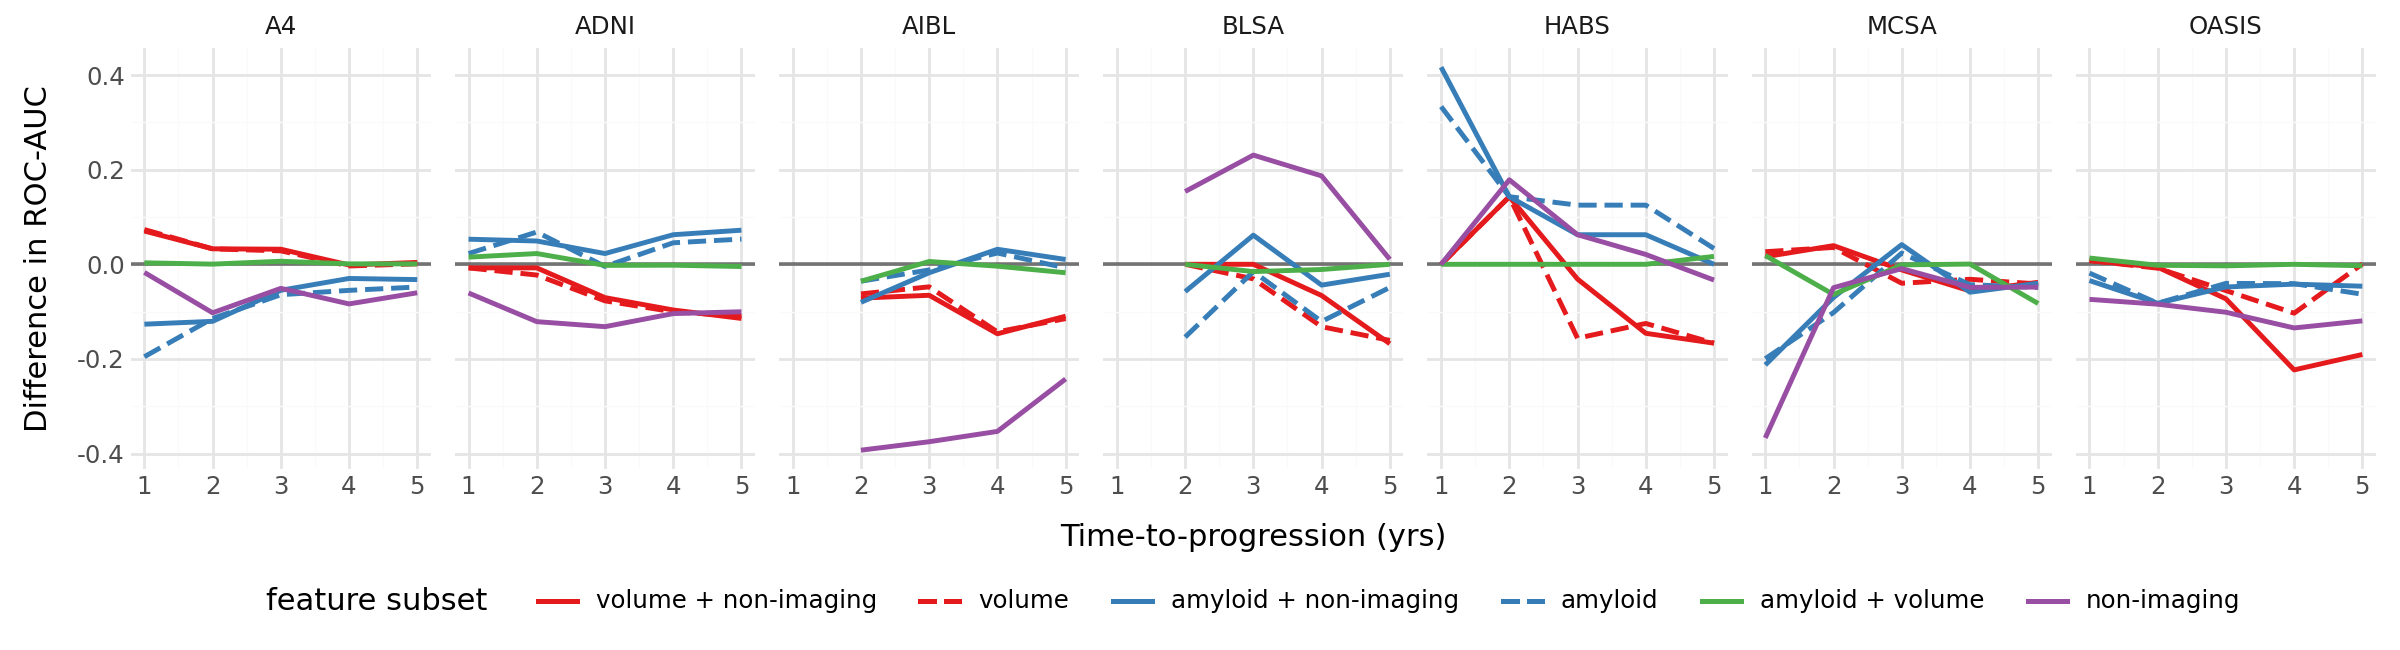

In [22]:
# plot difference in ROC AUC for test set
df = acc_nested_diff[acc_nested_diff["eval_dataset"] == "test_metrics"]
df = df[df["features"].isin(["vn", "v", "an", "a", "av", "n"])]
df["feature subset"] = pd.Categorical(
    df["feature subset"],
    categories = ["volume + non-imaging", "volume", "amyloid + non-imaging", "amyloid", "amyloid + volume", "non-imaging"], ordered = True
)

df = df[~df["leave_out_group"].isin(["FBP", "PIB", "aggregated_tracer", "aggregated_site"])]
df["hold-out site"] = pd.Categorical(
    df["leave_out_group"],
    categories = ['A4', 'ADNI', 'AIBL', 'BLSA', 'HABS', 'MCSA', 'OASIS']
)

custom_colors = {
    "volume + non-imaging": "#E41A1C",
    "volume": "#E41A1C",
    "amyloid + non-imaging": "#377EB8",
    "amyloid": "#377EB8",
    "amyloid + volume": "#4DAF4A",
    "non-imaging": "#984EA3"
}

nested_test = (ggplot(df, aes(x = "time_window", y = "auc_diff", color = "feature subset"))
    + geom_hline(yintercept = 0, color = "black", linetype = "solid", size = 0.75, alpha = 0.5)
    + geom_line(aes(linetype = "feature subset"), size = 1)
    # + scale_color_brewer(type = "qual", palette = "Set1")
    + scale_color_manual(values = custom_colors)
    + scale_linetype_manual(
        breaks = ["volume + non-imaging", "volume", "amyloid + non-imaging", "amyloid", "amyloid + volume", "non-imaging"],
        values = ["solid", "dashed", "solid", "dashed", "solid", "solid"]
    )
    + facet_wrap("leave_out_group", nrow = 1)
    + guides(color=guide_legend(nrow=1))
    + theme_minimal()
    + theme(figure_size = (12, 3.25), legend_position = "bottom", legend_key_spacing_x = 15, legend_box_spacing=0.01)
    + labs(x = "Time-to-progression (yrs)", y = "Difference in ROC-AUC")
)
# nested_test.save(os.path.join(odir_fig_nested, "nested_model_diff_auc_test_kleen.png"), dpi = 500)
nested_test

In [ ]:
# perform Delong test for nested models
score_delong = get_scores_for_delong(
    "/ceph/chpc/shared/aristeidis_sotiras_group/b.y.yang_scratch/BradenADLongitudinalPrediction/revision/nested_models",
    feature_list = ["avn", "an", "vn", "av", "a", "v", "n"]
)
# score_delong.to_csv("revisions/y_score_nested.csv")